# Comparative Study of CNN and Autoencoder Models for Pneumonia Detection from Chest X-Rays

## Objective
This project compares two deep learning approaches for pneumonia detection using chest X-ray images:

1. **Convolutional Neural Network (CNN)** for supervised binary classification
2. **Autoencoder (AE)** for unsupervised anomaly detection using reconstruction error

The goal is to evaluate how a standard supervised classifier compares to a reconstruction-based anomaly detection model on the same medical imaging task.

## Dataset

We use the **Chest X-Ray Images (Pneumonia)** dataset from Kaggle.

Expected folder structure:

chest_xray/
- train/
  - NORMAL/
  - PNEUMONIA/
- val/
  - NORMAL/
  - PNEUMONIA/
- test/
  - NORMAL/
  - PNEUMONIA/

The CNN is trained using both normal and pneumonia images.
The Autoencoder is trained using only normal images and detects pneumonia as an anomaly based on reconstruction error.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Run this ONLY if your JupyterHub environment is missing packages
# !pip install torch torchvision scikit-learn matplotlib pillow pandas

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [ ]:
# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
## Unzip Dataset (Optional)
"""
If you uploaded the Kaggle dataset as a `.zip` file, unzip it here.
If your dataset is already extracted, skip this section.
"""

'\nIf you uploaded the Kaggle dataset as a `.zip` file, unzip it here.\nIf your dataset is already extracted, skip this section.\n'

In [ ]:
# Uncomment ONLY if you uploaded chest_xray.zip and need to extract it
# !unzip chest_xray.zip

In [ ]:
# Change this path if needed
DATASET_ROOT = "/content/drive/MyDrive/ECE 542 Final Project/chest_xray"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

print("Train path:", TRAIN_DIR)
print("Val path:  ", VAL_DIR)
print("Test path: ", TEST_DIR)

Train path: /content/drive/MyDrive/ECE 542 Final Project/chest_xray/train
Val path:   /content/drive/MyDrive/ECE 542 Final Project/chest_xray/val
Test path:  /content/drive/MyDrive/ECE 542 Final Project/chest_xray/test


In [ ]:
IMAGE_SIZE = 128
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

In [ ]:
class ChestXRayDataset(Dataset):
    def __init__(self, root_dir, transform=None, normal_only=False, max_samples=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []

        # Label mapping: NORMAL=0, PNEUMONIA=1
        classes = ['NORMAL', 'PNEUMONIA']

        for label, cls in enumerate(classes):
            if normal_only and cls != 'NORMAL':
                continue

            cls_dir = os.path.join(root_dir, cls)

            if not os.path.exists(cls_dir):
                print(f"Warning: Missing directory -> {cls_dir}")
                continue

            for fname in os.listdir(cls_dir):
                fpath = os.path.join(cls_dir, fname)
                if os.path.isfile(fpath):
                    self.samples.append((fpath, label))

        # Optional sample cap for faster debugging
        if max_samples is not None:
            self.samples = self.samples[:max_samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('L')

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# Set max_samples to something like 1000 if JupyterHub is too slow
# Example: max_samples=1000
MAX_SAMPLES = None

train_dataset = ChestXRayDataset(TRAIN_DIR, transform=transform, max_samples=MAX_SAMPLES)
val_dataset   = ChestXRayDataset(VAL_DIR, transform=transform, max_samples=MAX_SAMPLES)
test_dataset  = ChestXRayDataset(TEST_DIR, transform=transform, max_samples=MAX_SAMPLES)

# Autoencoder train set: NORMAL images only
ae_train_dataset = ChestXRayDataset(TRAIN_DIR, transform=transform, normal_only=True, max_samples=MAX_SAMPLES)

# Autoencoder validation set: NORMAL images only (used for threshold selection)
ae_val_normal_dataset = ChestXRayDataset(VAL_DIR, transform=transform, normal_only=True, max_samples=MAX_SAMPLES)

print("CNN Train samples:", len(train_dataset))
print("CNN Val samples:  ", len(val_dataset))
print("CNN Test samples: ", len(test_dataset))
print("AE Train NORMAL:  ", len(ae_train_dataset))
print("AE Val NORMAL:    ", len(ae_val_normal_dataset))

CNN Train samples: 5216
CNN Val samples:   16
CNN Test samples:  624
AE Train NORMAL:   1341
AE Val NORMAL:     8


In [ ]:
import os

print("DATASET_ROOT exists:", os.path.exists(DATASET_ROOT))
print("TRAIN_DIR exists:", os.path.exists(TRAIN_DIR))
print("VAL_DIR exists:", os.path.exists(VAL_DIR))
print("TEST_DIR exists:", os.path.exists(TEST_DIR))

# Check what's actually inside your Data folder
print("\nContents of Data folder:")
print(os.listdir(DATASET_ROOT))

DATASET_ROOT exists: True
TRAIN_DIR exists: True
VAL_DIR exists: True
TEST_DIR exists: True

Contents of Data folder:
['test', 'train', 'val']


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

ae_train_loader = DataLoader(ae_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
ae_val_normal_loader = DataLoader(ae_val_normal_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
## Sample Images

## Display a few images to confirm the dataset is loading correctly.

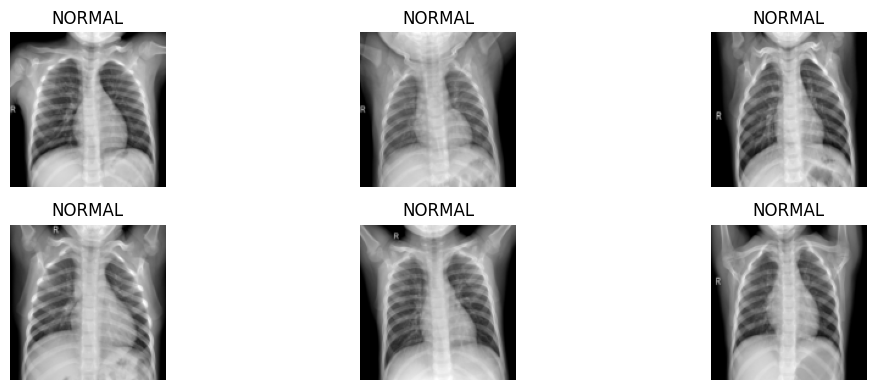

In [ ]:
def show_samples(dataset, num_images=6):
    plt.figure(figsize=(12, 4))
    for i in range(num_images):
        image, label = dataset[i]
        plt.subplot(2, 3, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title("NORMAL" if label == 0 else "PNEUMONIA")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_dataset, num_images=6)

## CNN Model

A simple convolutional neural network is used for supervised binary classification.
Output:
- 0 = NORMAL
- 1 = PNEUMONIA

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),   # 128x128
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 64x64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)                               # 16x16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)  # Binary output logit
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
cnn_model = SimpleCNN().to(device)

cnn_criterion = nn.BCEWithLogitsLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)

print(cnn_model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [ ]:
def train_cnn(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        running_train_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return train_losses, val_losses

In [ ]:
CNN_EPOCHS = 5  # Start with 3 if JupyterHub is slow

cnn_train_losses, cnn_val_losses = train_cnn(
    cnn_model,
    train_loader,
    val_loader,
    cnn_criterion,
    cnn_optimizer,
    epochs=CNN_EPOCHS
)

Epoch [1/3] | Train Loss: 0.3012 | Val Loss: 0.4662
Epoch [2/3] | Train Loss: 0.1409 | Val Loss: 0.4197
Epoch [3/3] | Train Loss: 0.1178 | Val Loss: 0.7486


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(cnn_train_losses, label="Train Loss")
plt.plot(cnn_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def evaluate_cnn(model, loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            preds = (probs > 0.5).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, prec, rec, f1, cm, np.array(all_probs), np.array(all_labels), np.array(all_preds)

In [ ]:
cnn_acc, cnn_prec, cnn_rec, cnn_f1, cnn_cm, cnn_probs, cnn_true, cnn_preds = evaluate_cnn(cnn_model, test_loader)

print("CNN Test Results")
print(f"Accuracy : {cnn_acc:.4f}")
print(f"Precision: {cnn_prec:.4f}")
print(f"Recall   : {cnn_rec:.4f}")
print(f"F1-Score : {cnn_f1:.4f}")

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

## Autoencoder Model

The autoencoder is trained only on **normal chest X-rays**.

Idea:
- Normal images should reconstruct well
- Pneumonia images should reconstruct worse
- High reconstruction error indicates an abnormal image

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),   # 128 -> 64
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 64 -> 32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 32 -> 16
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16 -> 32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 32 -> 64
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),   # 64 -> 128
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
ae_model = Autoencoder().to(device)

ae_criterion = nn.MSELoss()
ae_optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)

print(ae_model)

In [ ]:
def train_autoencoder(model, loader, criterion, optimizer, epochs=5):
    losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, _ in loader:
            images = images.to(device)

            optimizer.zero_grad()
            recon = model(images)
            loss = criterion(recon, images)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        losses.append(avg_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | AE Train Loss: {avg_loss:.6f}")

    return losses

In [ ]:
AE_EPOCHS = 5  # Start with 3 if slow

ae_train_losses = train_autoencoder(
    ae_model,
    ae_train_loader,
    ae_criterion,
    ae_optimizer,
    epochs=AE_EPOCHS
)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(ae_train_losses, label="AE Train Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def get_reconstruction_errors(model, loader):
    model.eval()
    errors = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            recon = model(images)

            # Mean squared error per image
            batch_errors = torch.mean((images - recon) ** 2, dim=[1, 2, 3])

            errors.extend(batch_errors.cpu().numpy())
            labels_list.extend(labels.numpy())

    return np.array(errors), np.array(labels_list)

## Threshold Selection for Autoencoder

The threshold is chosen using reconstruction errors from **validation NORMAL images only**.

A simple threshold is:

**threshold = mean(validation_error) + 2 × std(validation_error)**

If a test image has reconstruction error above this threshold, it is classified as **PNEUMONIA**.

In [ ]:
val_normal_errors, _ = get_reconstruction_errors(ae_model, ae_val_normal_loader)

ae_threshold = val_normal_errors.mean() + 2 * val_normal_errors.std()

print("Autoencoder Threshold:", ae_threshold)
print("Validation NORMAL Mean Error:", val_normal_errors.mean())
print("Validation NORMAL Std Error :", val_normal_errors.std())

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(val_normal_errors, bins=30, alpha=0.7)
plt.axvline(ae_threshold, linestyle='--', label=f"Threshold = {ae_threshold:.6f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Validation NORMAL Reconstruction Errors")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def evaluate_autoencoder(model, loader, threshold):
    model.eval()
    all_labels = []
    all_preds = []
    all_errors = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            recon = model(images)

            errors = torch.mean((images - recon) ** 2, dim=[1, 2, 3]).cpu().numpy()
            preds = (errors > threshold).astype(int)  # 1 = PNEUMONIA

            all_errors.extend(errors)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, prec, rec, f1, cm, np.array(all_errors), np.array(all_labels), np.array(all_preds)

In [ ]:
ae_acc, ae_prec, ae_rec, ae_f1, ae_cm, ae_errors, ae_true, ae_preds = evaluate_autoencoder(
    ae_model,
    test_loader,
    ae_threshold
)

print("Autoencoder Test Results")
print(f"Accuracy : {ae_acc:.4f}")
print(f"Precision: {ae_prec:.4f}")
print(f"Recall   : {ae_rec:.4f}")
print(f"F1-Score : {ae_f1:.4f}")

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=ae_cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot()
plt.title("Autoencoder Confusion Matrix")
plt.show()

In [ ]:
normal_test_errors = ae_errors[ae_true == 0]
pneumonia_test_errors = ae_errors[ae_true == 1]

plt.figure(figsize=(8, 5))
plt.hist(normal_test_errors, bins=30, alpha=0.6, label="NORMAL")
plt.hist(pneumonia_test_errors, bins=30, alpha=0.6, label="PNEUMONIA")
plt.axvline(ae_threshold, linestyle='--', label=f"Threshold = {ae_threshold:.6f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Autoencoder Reconstruction Error on Test Set")
plt.legend()
plt.grid(True)
plt.show()

## Reconstruction Examples

These examples help visualize how well the autoencoder reconstructs normal vs pneumonia images.

In [ ]:
def show_reconstruction_examples(model, dataset, num_examples=6):
    model.eval()

    fig, axes = plt.subplots(num_examples, 3, figsize=(10, 3 * num_examples))

    with torch.no_grad():
        for i in range(num_examples):
            image, label = dataset[i]
            input_img = image.unsqueeze(0).to(device)
            recon = model(input_img).cpu().squeeze().numpy()

            error = torch.mean((input_img.cpu() - torch.tensor(recon).unsqueeze(0).unsqueeze(0)) ** 2).item()

            axes[i, 0].imshow(image.squeeze(), cmap='gray')
            axes[i, 0].set_title(f"Original ({'NORMAL' if label == 0 else 'PNEUMONIA'})")
            axes[i, 0].axis('off')

            axes[i, 1].imshow(recon, cmap='gray')
            axes[i, 1].set_title("Reconstruction")
            axes[i, 1].axis('off')

            diff = np.abs(image.squeeze().numpy() - recon)
            axes[i, 2].imshow(diff, cmap='hot')
            axes[i, 2].set_title(f"Abs Diff\nError={error:.6f}")
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
show_reconstruction_examples(ae_model, test_dataset, num_examples=6)

## Comparative Results

Both models are evaluated using:

- Accuracy
- Precision
- Recallm
- F1-Score

Recall is especially important because failing to detect pneumonia is more clinically dangerous than a false positive.

In [ ]:
results = pd.DataFrame({
    "Model": ["CNN", "Autoencoder"],
    "Accuracy": [cnn_acc, ae_acc],
    "Precision": [cnn_prec, ae_prec],
    "Recall": [cnn_rec, ae_rec],
    "F1-Score": [cnn_f1, ae_f1]
})

results

In [ ]:
results.to_csv("model_comparison_results.csv", index=False)
print("Saved: model_comparison_results.csv")

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.35

cnn_values = [cnn_acc, cnn_prec, cnn_rec, cnn_f1]
ae_values  = [ae_acc, ae_prec, ae_rec, ae_f1]

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, cnn_values, width, label="CNN")
plt.bar(x + width/2, ae_values, width, label="Autoencoder")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("CNN vs Autoencoder Performance Comparison")
plt.legend()
plt.grid(True, axis='y')
plt.show()

## Robustness Testing (Optional)

To evaluate robustness, we apply a small perturbation to test images and compare how performance changes.

This helps determine how sensitive each model is to variations in input data.

In [ ]:
class NoisyDataset(Dataset):
    def __init__(self, base_dataset, noise_std=0.05):
        self.base_dataset = base_dataset
        self.noise_std = noise_std

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        noise = torch.randn_like(image) * self.noise_std
        noisy_image = torch.clamp(image + noise, 0.0, 1.0)
        return noisy_image, label

In [ ]:
noisy_test_dataset = NoisyDataset(test_dataset, noise_std=0.05)
noisy_test_loader = DataLoader(noisy_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# CNN on noisy data
cnn_acc_n, cnn_prec_n, cnn_rec_n, cnn_f1_n, _, _, _, _ = evaluate_cnn(cnn_model, noisy_test_loader)

# AE on noisy data
ae_acc_n, ae_prec_n, ae_rec_n, ae_f1_n, _, _, _, _ = evaluate_autoencoder(ae_model, noisy_test_loader, ae_threshold)

robustness_results = pd.DataFrame({
    "Model": ["CNN", "Autoencoder"],
    "Accuracy (Clean)": [cnn_acc, ae_acc],
    "Accuracy (Noisy)": [cnn_acc_n, ae_acc_n],
    "Recall (Clean)": [cnn_rec, ae_rec],
    "Recall (Noisy)": [cnn_rec_n, ae_rec_n],
    "F1 (Clean)": [cnn_f1, ae_f1],
    "F1 (Noisy)": [cnn_f1_n, ae_f1_n]
})

robustness_results

## Conclusion

This project compared a supervised CNN classifier and an unsupervised Autoencoder-based anomaly detector for pneumonia detection from chest X-rays.

### Key Observations
- The **CNN** generally provides stronger classification performance because it directly learns from labeled normal and pneumonia examples.
- The **Autoencoder** offers a useful alternative when labels are limited by learning only the structure of normal images and flagging abnormal cases through reconstruction error.
- In medical diagnosis, **recall** is especially important because missed pneumonia cases can have serious consequences.

### Interpretation
If the CNN achieves higher recall and F1-score, it suggests that supervised learning is more effective on this dataset when labeled data is available.
If the Autoencoder shows reasonable recall, it demonstrates that anomaly detection can still be a viable approach, especially in scenarios where abnormal labels are scarce.

### Future Work
Future improvements could include:
- Using deeper CNN architectures
- Tuning the autoencoder threshold more carefully
- Applying data augmentation
- Testing robustness under image noise, brightness changes, or slight rotations
- Exploring variational autoencoders or transfer learning methods